Part 0: Exploratory Data Analysis

In [1]:
#import settings
from pathlib import Path
import sys

p = Path.cwd().resolve()
repo_root = next(parent for parent in [p, *p.parents] if (parent / "src").exists())
sys.path.insert(0, str(repo_root / "src"))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dataset import load_image_paths_and_labels
from PIL import Image
from tqdm import tqdm
from collections import defaultdict, Counter

In [3]:
#Data_directory
ROOT_DIR = "C:/Users/Kwame Boateng/Documents/GitHub/AI_In_Medicine_Project_1/data/caltech-101"
EXCLUDE = {"BACKGROUND_Google"}

In [4]:
plt.rcParams.update({
    'font.size': 14,          # Global font size
    'axes.titlesize': 18,     # Title size
    'axes.labelsize': 16,     # X and Y label size
    'xtick.labelsize': 14,    # X axis numbers
    'ytick.labelsize': 14,    # Y axis numbers
    'legend.fontsize': 14     # Legend text size
})

In [5]:
#Load Images and labels
paths, labels, label2idx = load_image_paths_and_labels(
    ROOT_DIR,
    exclude={"BACKGROUND_Google"}
)

print("Total images:", len(paths))

Total images: 8677


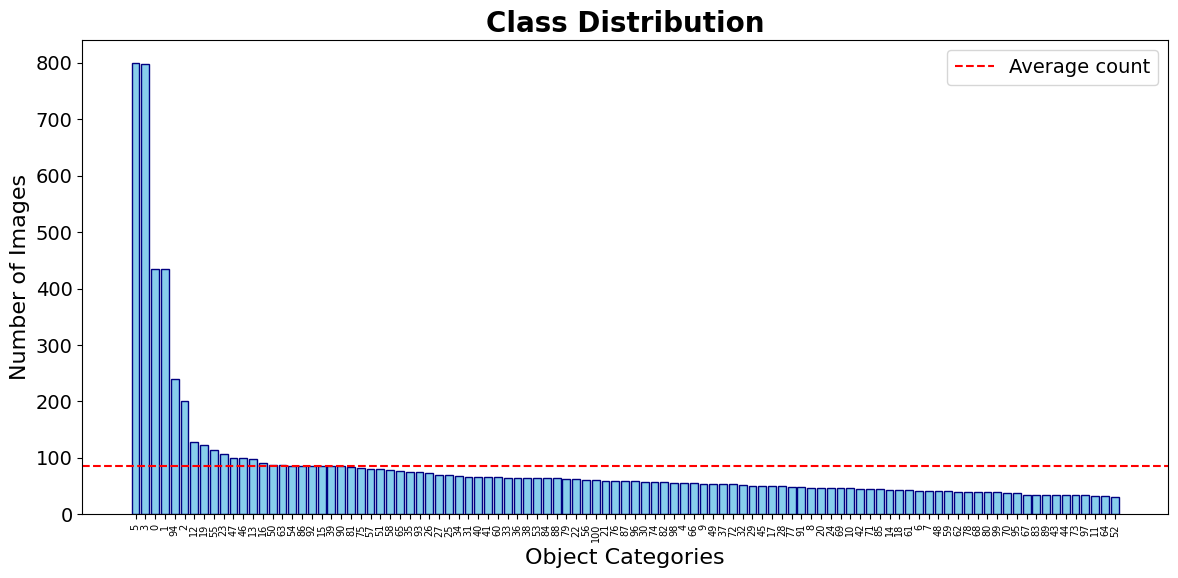

In [ ]:
class_counts = Counter(labels)
sorted_data = class_counts.most_common()
sorted_classes, sorted_counts = zip(*sorted_data)

plt.figure(figsize=(12, 6))


x_pos = range(len(sorted_classes))

plt.bar(x_pos, sorted_counts, color='skyblue', edgecolor='navy', width=0.8)

plt.xticks(x_pos, sorted_classes, rotation=90, fontsize=7)

plt.title("Class Distribution", fontsize=20, fontweight='bold')
plt.xlabel("Object Categories", fontsize=16)
plt.ylabel("Number of Images", fontsize=16)

plt.axhline(sum(sorted_counts)/len(sorted_counts), color='red', linestyle='--', label='Average count')

plt.legend()
plt.tight_layout()
plt.savefig("class_distribution.png", bbox_inches='tight', dpi=300)
plt.show()

In [8]:
#Compute Image Dimensions
heights = []
widths = []

for path in tqdm(paths):
    with Image.open(path) as img:
        w, h = img.size  # PIL gives (width, height)
        widths.append(w)
        heights.append(h)

heights = np.array(heights)
widths = np.array(widths)

100%|██████████| 8677/8677 [00:11<00:00, 741.33it/s]


In [9]:
#Statistics
print("Height stats:")
print("  Min:", heights.min())
print("  Max:", heights.max())
print("  Mean:", heights.mean())

print("\nWidth stats:")
print("  Min:", widths.min())
print("  Max:", widths.max())
print("  Mean:", widths.mean())

Height stats:
  Min: 92
  Max: 494
  Mean: 239.5194191540855

Width stats:
  Min: 80
  Max: 708
  Mean: 297.7595943298375


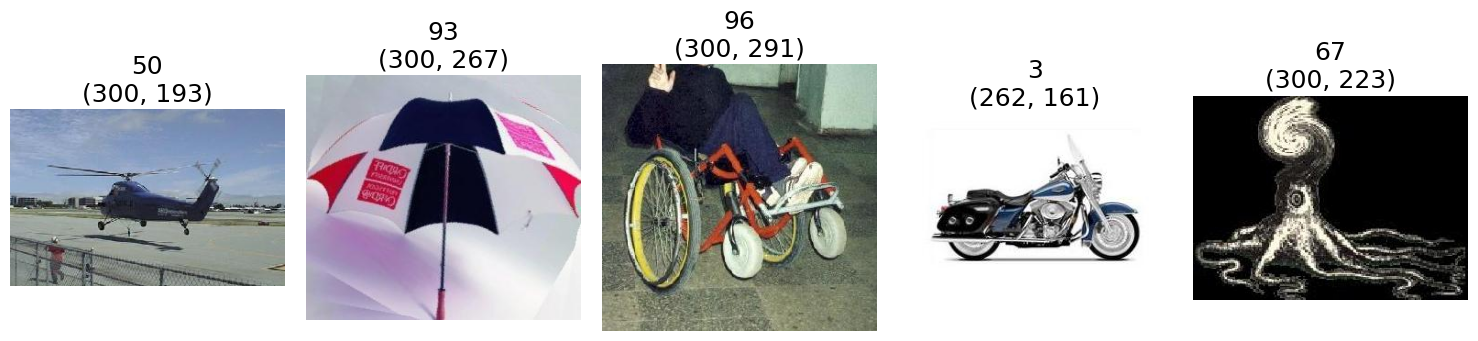

In [10]:
def show_sample_grid(paths, labels, n=5):
    unique_labels = list(set(labels))
    selected_labels = np.random.choice(unique_labels, n, replace=False)
    
    fig, axes = plt.subplots(1, n, figsize=(15, 5))
    for i, label in enumerate(selected_labels):
        # Find first image with this label
        idx = labels.index(label)
        img = Image.open(paths[idx])
        axes[i].imshow(img)
        axes[i].set_title(f"{label}\n{img.size}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

show_sample_grid(paths, labels)

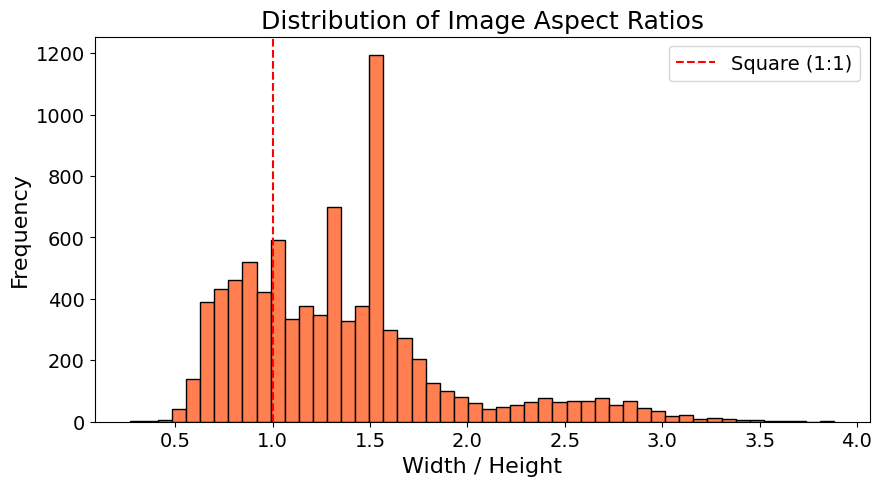

Percentage of non-square images: 97.53%


In [11]:
aspect_ratios = widths / heights

plt.figure(figsize=(10, 5))
plt.hist(aspect_ratios, bins=50, color='coral', edgecolor='black')
plt.axvline(1.0, color='red', linestyle='--', label='Square (1:1)')
plt.title("Distribution of Image Aspect Ratios")
plt.xlabel("Width / Height")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(f"Percentage of non-square images: {100 * np.sum(aspect_ratios != 1.0) / len(aspect_ratios):.2f}%")

In [ ]:

"""Index to class labels"""


idx2label = {v: k for k, v in label2idx.items()}
sorted_indices = sorted(idx2label.keys())


print("\\begin{table}[h!]")
print("\\centering")
print("\\resizebox{\\textwidth}{!}{")
print("\\begin{tabular}{ll | ll | ll}")
print("\\toprule")
print("\\textbf{Idx} & \\textbf{Class Name} & \\textbf{Idx} & \\textbf{Class Name} & \\textbf{Idx} & \\textbf{Class Name} \\\\")
print("\\midrule")


for i in range(0, len(sorted_indices), 3):
    # Column 1
    col1 = f"{sorted_indices[i]} & {idx2label[sorted_indices[i]]}" if i < len(sorted_indices) else "&"
    
    # Column 2
    col2 = f"{sorted_indices[i+1]} & {idx2label[sorted_indices[i+1]]}" if i+1 < len(sorted_indices) else "&"
    
    # Column 3
    col3 = f"{sorted_indices[i+2]} & {idx2label[sorted_indices[i+2]]}" if i+2 < len(sorted_indices) else "&"
    
    row = f"{col1} & {col2} & {col3} \\\\".replace("_", "\\_")
    print(row)

#Print the LaTeX Footer
print("\\bottomrule")
print("\\end{tabular}}")
print("\\caption{Mapping of dataset class indices to their semantic category labels.}")
print("\\label{tab:class_mapping}")
print("\\end{table}")

\begin{table}[h!]
\centering
\resizebox{\textwidth}{!}{
\begin{tabular}{ll | ll | ll}
\toprule
\textbf{Idx} & \textbf{Class Name} & \textbf{Idx} & \textbf{Class Name} & \textbf{Idx} & \textbf{Class Name} \\
\midrule
0 & Faces & 1 & Faces\_easy & 2 & Leopards \\
3 & Motorbikes & 4 & accordion & 5 & airplanes \\
6 & anchor & 7 & ant & 8 & barrel \\
9 & bass & 10 & beaver & 11 & binocular \\
12 & bonsai & 13 & brain & 14 & brontosaurus \\
15 & buddha & 16 & butterfly & 17 & camera \\
18 & cannon & 19 & car\_side & 20 & ceiling\_fan \\
21 & cellphone & 22 & chair & 23 & chandelier \\
24 & cougar\_body & 25 & cougar\_face & 26 & crab \\
27 & crayfish & 28 & crocodile & 29 & crocodile\_head \\
30 & cup & 31 & dalmatian & 32 & dollar\_bill \\
33 & dolphin & 34 & dragonfly & 35 & electric\_guitar \\
36 & elephant & 37 & emu & 38 & euphonium \\
39 & ewer & 40 & ferry & 41 & flamingo \\
42 & flamingo\_head & 43 & garfield & 44 & gerenuk \\
45 & gramophone & 46 & grand\_piano & 47 & hawksbill \\
